<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Model Explainability using SHAP**
# Objective:
To analyze global and local explanations using SHAP.


##VAE + GAN (PyTorch)

This notebook implements a combined Variational Autoencoder (VAE) and Generative Adversarial Network (GAN) using PyTorch for generating images, specifically focusing on the MNIST dataset.E

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### 1. Configuration

This section defines the essential parameters for the model, including device, batch size, latent dimension for the VAE/GAN, and the number of training epochs.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 20
epochs = 5

### 2. Data Loading

Here, the MNIST dataset is loaded. Images are converted to tensors, but no normalization is applied to keep the pixel values in \[0, 1\] range, which is suitable for the VAE's Sigmoid output and later scaled for the GAN's Tanh output.

In [11]:
transform = transforms.ToTensor()

train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

### 3. VAE Model Definition

The Variational Autoencoder (VAE) consists of an encoder that maps input images to a latent space (mean `mu` and log-variance `logvar`) and a decoder that reconstructs images from samples of this latent space. The `reparameterize` method allows for backpropagation through the sampling process. The decoder uses a `Sigmoid` activation to output pixel values in the \[0, 1\] range, matching the input image scale.

In [12]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # 🔥 FIX: matches BCE
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, 784)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### 4. GAN Model Definition (Generator and Discriminator)

The Generative Adversarial Network (GAN) comprises two competing networks: a Generator and a Discriminator.

-   **Generator**: Takes random noise from the latent space and transforms it into an image. It uses `Tanh` activation in the final layer to produce pixel values in the \[-1, 1\] range, which is common for GANs.
-   **Discriminator**: Takes an image (either real or generated) and tries to classify it as real (output close to 1) or fake (output close to 0). It uses `Sigmoid` activation for binary classification.

In [13]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh()  # GAN uses [-1,1]
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 784))

### 5. Model and Optimizer Initialization

This section initializes the VAE, Generator, and Discriminator models, moving them to the appropriate device (CPU or GPU). It also sets up Adam optimizers for each model with specific learning rates and beta values. `nn.BCELoss()` is chosen as the criterion for the GAN, suitable for binary classification.

In [14]:
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
gen_optimizer = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()

### 6. Training Loop

The training loop iterates over the specified number of epochs. Inside each epoch, it processes batches of images from the `train_loader`. The training process involves three main steps for each batch:

1.  **VAE Training**: Calculates reconstruction loss and KL divergence, then performs backpropagation and updates VAE weights.
2.  **Discriminator Training**: The discriminator is trained to distinguish between real images (scaled to \[-1, 1\] for GAN compatibility) and fake images generated by the GAN. It aims to minimize loss on both real and fake images.
3.  **Generator Training**: The generator is trained to produce images that can fool the discriminator, aiming for the discriminator to classify its outputs as real.

In [15]:
print("Training Started...\n")

for epoch in range(epochs):
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        batch_size_curr = imgs.size(0)

        # 🔥 FIX: scale for GAN only
        imgs_gan = imgs * 2 - 1  # [0,1] → [-1,1]

        real_labels = torch.ones(batch_size_curr, 1).to(device)
        fake_labels = torch.zeros(batch_size_curr, 1).to(device)

        # -------- VAE --------
        vae_optimizer.zero_grad()

        recon, mu, logvar = vae(imgs)

        recon_loss = nn.functional.binary_cross_entropy(
            recon, imgs.view(-1, 784), reduction='sum'
        )

        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        vae_loss = (recon_loss + kld) / batch_size_curr
        vae_loss.backward()
        vae_optimizer.step()

        # -------- GAN: Discriminator --------
        disc_optimizer.zero_grad()

        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = gen(z)

        real_loss = criterion(disc(imgs_gan), real_labels)
        fake_loss = criterion(disc(fake_imgs.detach()), fake_labels)

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        disc_optimizer.step()

        # -------- GAN: Generator --------
        gen_optimizer.zero_grad()

        g_loss = criterion(disc(fake_imgs), real_labels)
        g_loss.backward()
        gen_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] | VAE: {vae_loss.item():.2f} | G: {g_loss.item():.2f} | D: {d_loss.item():.2f}")

Training Started...

Epoch [1/5] | VAE: 132.44 | G: 0.60 | D: 0.52
Epoch [2/5] | VAE: 114.09 | G: 1.80 | D: 0.47
Epoch [3/5] | VAE: 112.17 | G: 1.96 | D: 0.31
Epoch [4/5] | VAE: 114.66 | G: 1.90 | D: 0.28
Epoch [5/5] | VAE: 108.08 | G: 1.44 | D: 0.41


### 7. Visualization

After training, this section provides a visualization of generated images from both the VAE's decoder and the GAN's generator. It samples random points from the latent space and uses the trained models to generate images, displaying them in a 2x10 grid. The GAN's output is rescaled from \[-1, 1\] to \[0, 1\] for proper display.

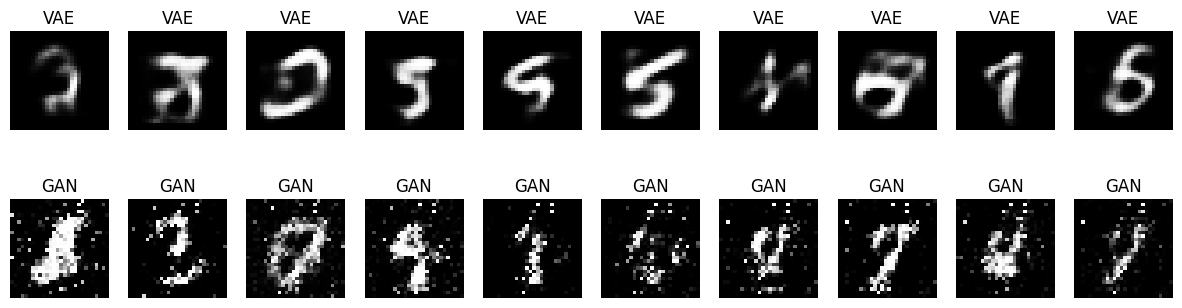

In [17]:
def visualize():
    vae.eval()
    gen.eval()

    with torch.no_grad():
        z = torch.randn(10, latent_dim).to(device)

        vae_imgs = vae.decoder(z)
        gan_imgs = gen(z)

        fig, axes = plt.subplots(2, 10, figsize=(15, 4))

        for i in range(10):
            axes[0, i].imshow(vae_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[0, i].set_title("VAE")
            axes[0, i].axis('off')

            # 🔥 FIX: rescale GAN output [-1,1] → [0,1]
            img = (gan_imgs[i].cpu().view(28, 28) + 1) / 2
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title("GAN")
            axes[1, i].axis('off')

        plt.show()

visualize()